# Context Maintenance and Retrieval (CMR)

> A computational model of episodic memory search that uses temporal context to guide free recall.

The Context Maintenance and Retrieval model implements retrieved-context theory, which posits that episodic retrieval is driven by a representation that evolves over time, tying each item to the contextual features present during encoding and later accessing those associations to guide retrieval [@howard2002distributed; @polyn2009context; @morton2016predictive].

CMR explains several benchmark phenomena in free recall:

- **Recency effect**: Items from the end of a list are often recalled first, because the end-of-list context is similar to the context at test onset.
- **Primacy effect**: Items from the beginning of a list are recalled more often, due to stronger associative encoding.
- **Lag-contiguity effect**: Recalling one item increases the probability of recalling nearby items, because reinstating an item's encoding context cues items with similar contexts.

This notebook walks through a simulated free recall trial, introducing each CMR method as it becomes relevant to the unfolding dynamics.

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
import matplotlib.pyplot as plt
from jaxcmr.models.cmr import CMR, make_factory
from jaxcmr.state_analysis import plot_model_state

---

## Creating a Model

CMR has a compositional architecture: the model is assembled from four pluggable components that can be swapped to create model variants.

- **Context** — the temporal context representation that drifts during encoding and retrieval
- **$M^{FC}$** (item-to-context memory) — associates items with their encoding contexts, enabling context reinstatement at recall
- **$M^{CF}$** (context-to-item memory) — associates contexts with items, enabling context-cued retrieval
- **Termination policy** — governs when recall stops

The default implementations use linear associative memories and an exponential stopping rule, but alternative implementations (e.g., instance-based memory, different termination dynamics) can be substituted via factory functions.

In [3]:
#| echo: false
show_doc(CMR.__init__)

---

### CMR.__init__

>      CMR.__init__ (list_length:int,
>                    parameters:Mapping[str,jaxtyping.Float[Array,'']|float|int]
>                    , mfc_create_fn:jaxcmr.typing.MemoryCreateFn=<function
>                    init_mfc>,
>                    mcf_create_fn:jaxcmr.typing.MemoryCreateFn=<function
>                    init_mcf>,
>                    context_create_fn:jaxcmr.typing.ContextCreateFn=<function
>                    init>, termination_policy_create_fn:jaxcmr.typing.Terminati
>                    onPolicyCreateFn=<class
>                    'jaxcmr.components.termination.PositionalTermination'>)

*Context Maintenance and Retrieval model of memory search.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| list_length | int |  | Number of items in the study list. |
| parameters | Mapping |  | Model parameters including drift rates, learning rates, and<br>sensitivity values. |
| mfc_create_fn | MemoryCreateFn | init_mfc | Factory function for item-to-context memory (M_FC). |
| mcf_create_fn | MemoryCreateFn | init_mcf | Factory function for context-to-item memory (M_CF). |
| context_create_fn | ContextCreateFn | init | Factory function for temporal context representation. |
| termination_policy_create_fn | TerminationPolicyCreateFn | PositionalTermination | Factory function for recall termination policy. |

The `parameters` dictionary configures the model's cognitive dynamics:

| Symbol | Parameter | Description |
|--------|-----------|-------------|
| $\beta_{\text{enc}}$ | `encoding_drift_rate` | Rate of context drift during item encoding |
| $\beta_{\text{start}}$ | `start_drift_rate` | Amount of start-of-list context reinstated before recall |
| $\beta_{\text{rec}}$ | `recall_drift_rate` | Rate of context drift during recall |
| $\gamma$ | `learning_rate` | Learning rate for updates to $M^{FC}$ |
| $\phi_s$ | `primacy_scale` | Scale of the primacy gradient for $M^{CF}$ learning |
| $\phi_d$ | `primacy_decay` | Decay rate of the primacy gradient |
| $\delta$ | `item_support` | Pre-experimental self-association in $M^{CF}$ |
| $\alpha$ | `shared_support` | Uniform pre-experimental cross-item support in $M^{CF}$ |
| $\tau$ | `choice_sensitivity` | Exponential scaling during the recall competition |
| $\theta_s$ | `stop_probability_scale` | Baseline of the stopping probability |
| $\theta_r$ | `stop_probability_growth` | Growth rate of stopping probability over outputs |

In [4]:
#| code-summary: Parameter configuration
params = {
    "encoding_drift_rate": 0.7,
    "start_drift_rate": 0.6,
    "recall_drift_rate": 0.85,
    "learning_rate": 0.4,
    "primacy_scale": 8.0,
    "primacy_decay": 1.0,
    "item_support": 6.0,
    "shared_support": 0.02,
    "choice_sensitivity": 1.5,
    "stop_probability_scale": 0.005,
    "stop_probability_growth": 0.4,
    "learn_after_context_update": True,
    "allow_repeated_recalls": False,
}

At initialization, context is a vector of length `list_length + 1` with only the start-of-list unit active. The memory components contain pre-experimental associations: $M^{FC}$ links each item to a unique context unit (weight $1 - \gamma$), while $M^{CF}$ gives each item stronger self-support ($\delta$) than the shared cross-item support ($\alpha$). No items are recallable until they have been studied.

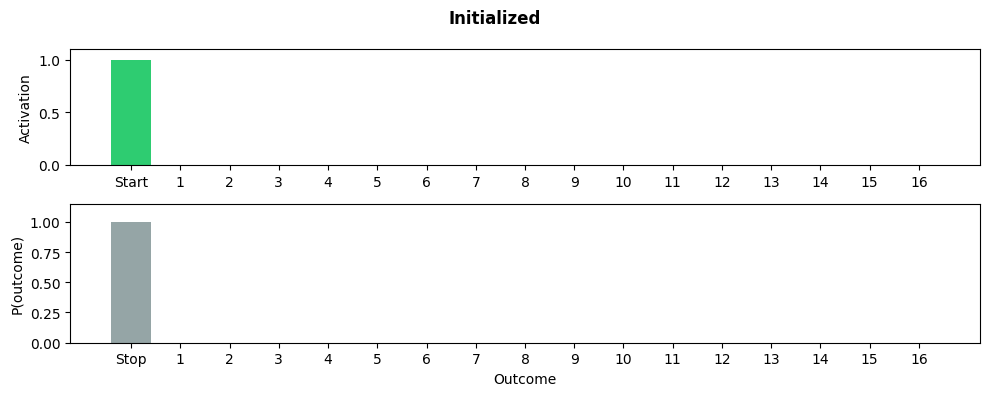

In [5]:
#| code-summary: Create a CMR model for a 16-item list
#| label: fig-init
#| fig-cap: "A fresh model before any items have been studied."
model = CMR(list_length=16, parameters=params)
plot_model_state(model, "Initialized")

---

## Encoding Phase

With our model initialized, we can simulate the study phase of a free recall experiment. Each item presentation triggers two key processes: the temporal context drifts to incorporate the new item, and bidirectional associations form between the item and its encoding context.

The `experience_item` method handles both:

In [6]:
#| echo: false
show_doc(CMR.experience_item)

---

### CMR.experience_item

>      CMR.experience_item (item_index:jaxtyping.Integer[Array,'']|int)

*Simulate encoding of an item during study, updating context and memories.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| item_index | jaxtyping.Integer[Array, ''] \| int | Index of the item to experience (0-indexed). |
| **Returns** | **CMR** | **Updated model state after encoding the item.** |

When we call `experience_item(0)`, the item's feature representation probes $M^{FC}$ to retrieve associated context, which is then integrated into the current state:

$$
c_i = \rho_i \, c_{i-1} + \beta_{\text{enc}} \, c_i^{\text{IN}}
$$

where $\rho_i = \sqrt{1 + \beta^2 \left[ (c_{i-1} \cdot c_i^{\text{IN}})^2 - 1 \right]} - \beta (c_{i-1} \cdot c_i^{\text{IN}})$ maintains unit length. Simultaneously, the model strengthens bidirectional associations: $M^{FC}$ learns with rate $\gamma$, while $M^{CF}$ learns with a primacy-scaled rate $\phi_i = \phi_s e^{-\phi_d(i-1)} + 1$ that gives early items stronger context-to-item associations.

Let's encode the first item and observe the changes:

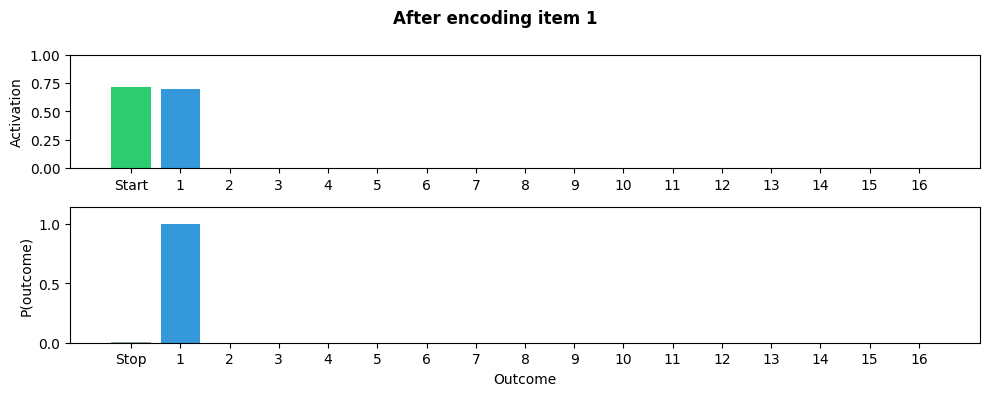

In [7]:
#| code-summary: Encode item 1
#| label: fig-encode-1
#| fig-cap: "After encoding item 1. Context has drifted; item 1 is now recallable."
model = model.experience_item(0)
plot_model_state(model, "After encoding item 1")

As encoding proceeds, context accumulates a recency gradient—recent items have stronger activation than early items. Meanwhile, the primacy gradient in $M^{CF}$ ensures early items retain strong associations despite their fading contextual activation.

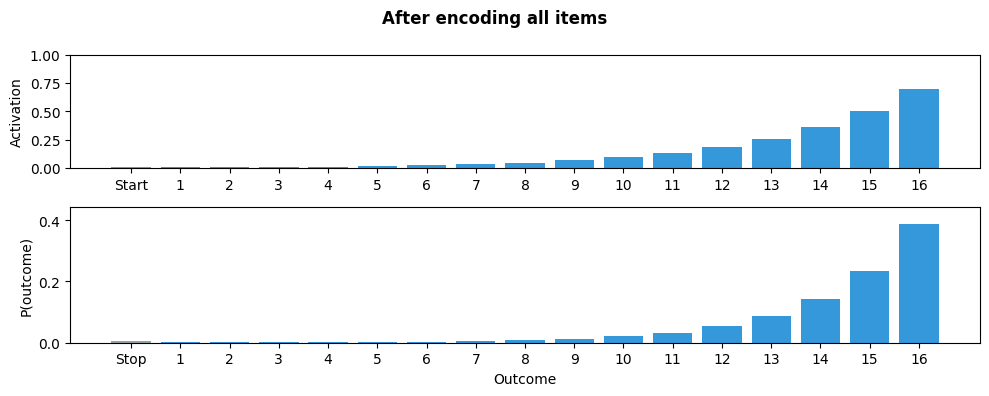

In [8]:
#| code-summary: Encode all 16 items
#| label: fig-encode-all
#| fig-cap: "After encoding all items. The U-shaped outcome probabilities reflect primacy (item 1) competing with recency (item 16)."
for i in range(1, 16):
    model = model.experience_item(i)
plot_model_state(model, "After encoding all items")

:::{.callout-note}
`experience(choice)` provides a 1-indexed interface matching experimental data formats, where 0 means "no event."
:::

---

## Retrieval Phase

With all items encoded, the model is ready for retrieval. But before recall begins, CMR partially reinstates the start-of-list context—this is what `start_retrieving` does:

In [9]:
#| echo: false
show_doc(CMR.start_retrieving)

---

### CMR.start_retrieving

>      CMR.start_retrieving ()

*Transition from study to retrieval mode by reinstating start context.*

This operation integrates the initial context vector $c_0$ with the current context at rate $\beta_{\text{start}}$:

$$
c_{\text{start}} = \rho \, c_N + \beta_{\text{start}} \, c_0
$$

The resulting retrieval cue reflects two competing influences: recency from the end-of-list context, and primacy from stronger $M^{CF}$ associations. Together these produce the characteristic U-shaped serial position curve:

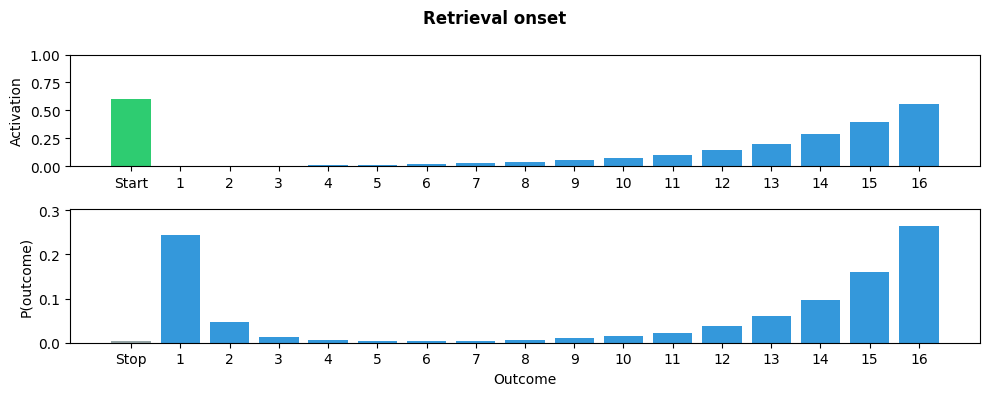

In [10]:
#| code-summary: Transition to retrieval
#| label: fig-start-retrieval
#| fig-cap: "At retrieval onset. High probability for both early items (primacy) and late items (recency)."
model = model.start_retrieving()
plot_model_state(model, "Retrieval onset")

Now we can simulate recall. When an item is retrieved, `retrieve_item` reinstates its encoding context via $M^{FC}$, records the recall, and (by default) marks the item as no longer recallable:

In [11]:
#| echo: false
show_doc(CMR.retrieve_item)

---

### CMR.retrieve_item

>      CMR.retrieve_item (item_index:jaxtyping.Integer[Array,'']|int)

*Simulate retrieval of a specific item, updating context and records.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| item_index | jaxtyping.Integer[Array, ''] \| int | Index of the item to retrieve (0-indexed). |
| **Returns** | **CMR** | **Updated model state after retrieval.** |

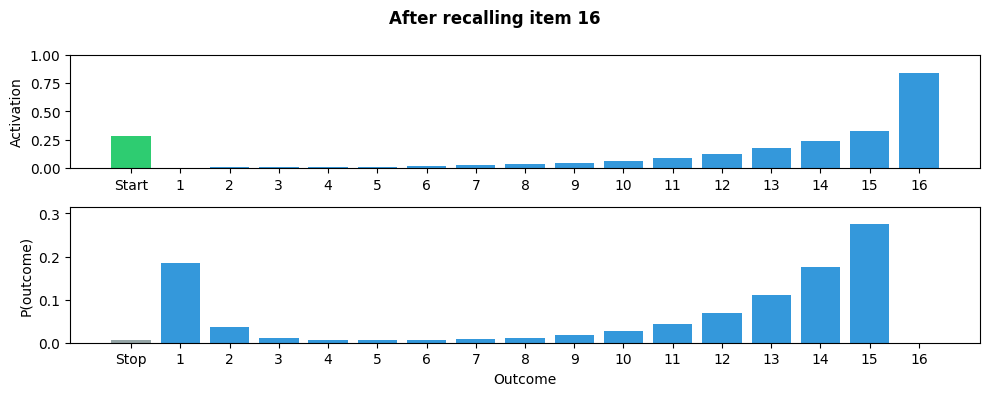

In [12]:
#| code-summary: Recall item 16
#| label: fig-recall-1
#| fig-cap: "After recalling item 16. Context shifts toward item 16's encoding context, making item 15 most probable."
model = model.retrieve_item(15)
plot_model_state(model, "After recalling item 16")

Recalling item 16 reinstated a context similar to when item 16 was studied, which was temporally close to item 15. This is the contiguity effect in action.

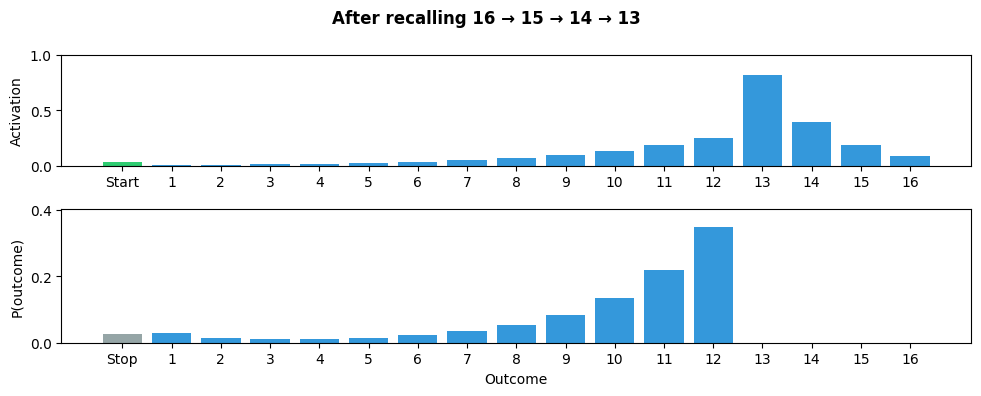

In [13]:
#| code-summary: Continue recall sequence
#| label: fig-recall-sequence
#| fig-cap: "After recalling items 15, 14, and 13. Backward recall pattern: 16 → 15 → 14 → 13."
model = model.retrieve_item(14)
model = model.retrieve_item(13)
model = model.retrieve_item(12)
plot_model_state(model, "After recalling 16 → 15 → 14 → 13")

Each recall shifted probability toward the next earlier item, producing the backward recall pattern 16 → 15 → 14 → 13.

---

## Probability Computations

The visualizations above show outcome probabilities, but how are these computed? CMR uses a Luce choice rule over item activations, combined with a termination probability.

First, `activations` probes $M^{CF}$ with the current context to get raw support for each item:

In [14]:
#| echo: false
show_doc(CMR.activations)

---

### CMR.activations

>      CMR.activations ()

*Compute retrieval activations for all items from context-to-item memory.*

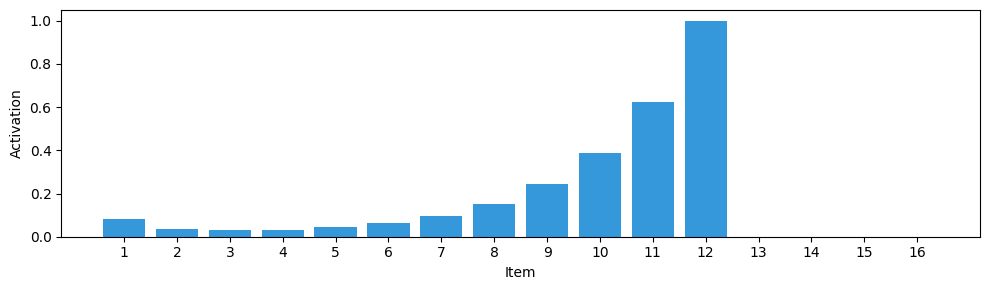

In [15]:
#| code-summary: Examine raw activations
#| label: fig-activations
#| fig-cap: "Raw retrieval activations after recalling items 16, 15, 14, and 13."
activations = model.activations()
colors = ["#e74c3c" if not model.recallable[i] else "#3498db" for i in range(16)]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(1, 17), activations, color=colors)
ax.set_xlabel("Item")
ax.set_ylabel("Activation")
ax.set_xticks(range(1, 17))
plt.tight_layout()
plt.show()

Second, `stop_probability` determines the probability of terminating recall at this output position. The default termination policy (which can be swapped for alternatives) uses an exponential rule $P(\text{stop}, j) = \theta_s e^{j \theta_r}$ where $j$ is the output position:

In [16]:
#| echo: false
show_doc(CMR.stop_probability)

---

### CMR.stop_probability

>      CMR.stop_probability ()

*Compute probability of terminating recall.*

Finally, `outcome_probabilities` combines these via the Luce choice rule:

$$
P(i) = (1 - P(\text{stop})) \frac{A_i^\tau}{\sum_k A_k^\tau}
$$

The returned vector has `list_length + 1` elements: index 0 is $P(\text{stop})$, indices 1–N are item probabilities:

In [17]:
#| echo: false
show_doc(CMR.outcome_probabilities)

---

### CMR.outcome_probabilities

>      CMR.outcome_probabilities ()

*Compute probabilities for all possible retrieval outcomes.*

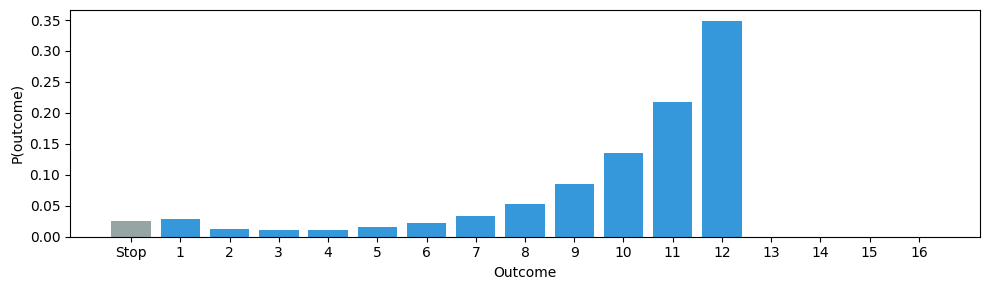

In [18]:
#| code-summary: Examine outcome probabilities
#| label: fig-outcome-probs
#| fig-cap: "Outcome probabilities combining activations, stop probability, and the Luce choice rule."
probs = model.outcome_probabilities()
labels = ["Stop"] + [str(i) for i in range(1, 17)]
colors = ["#95a5a6"] + ["#e74c3c" if not model.recallable[i] else "#3498db" for i in range(16)]

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(labels, probs, color=colors)
ax.set_xlabel("Outcome")
ax.set_ylabel("P(outcome)")
plt.tight_layout()
plt.show()

---

## Additional Methods

The following methods provide convenience interfaces and fine-grained probability queries. `retrieve` and `experience` offer 1-indexed interfaces matching experimental data formats (where 0 means "stop" or "no event"):

In [19]:
#| echo: false
show_doc(CMR.retrieve)

---

### CMR.retrieve

>      CMR.retrieve (choice:jaxtyping.Integer[Array,'']|int)

*Simulate a retrieval event.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| choice | jaxtyping.Integer[Array, ''] \| int | Index of item to retrieve (1-indexed), or 0 to terminate<br>recall. |
| **Returns** | **CMR** | **Updated model state after the retrieval event.** |

In [20]:
#| echo: false
show_doc(CMR.experience)

---

### CMR.experience

>      CMR.experience (choice:jaxtyping.Integer[Array,'']|int)

*Simulate a study event.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| choice | jaxtyping.Integer[Array, ''] \| int | Index of item to experience (1-indexed). A value of 0 is<br>ignored and returns the model unchanged. |
| **Returns** | **CMR** | **Updated model state after the study event.** |

`item_probability` and `outcome_probability` return individual probabilities rather than the full vector:

In [21]:
#| echo: false
show_doc(CMR.item_probability)

---

### CMR.item_probability

>      CMR.item_probability (item_index:jaxtyping.Integer[Array,'']|int)

*Compute probability of retrieving a specific item, assuming recall continues.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| item_index | jaxtyping.Integer[Array, ''] \| int | Index of the item (0-indexed). |
| **Returns** | **Float[Array, '']** | **Probability of retrieving the specified item.** |

In [22]:
#| echo: false
show_doc(CMR.outcome_probability)

---

### CMR.outcome_probability

>      CMR.outcome_probability (choice:jaxtyping.Integer[Array,'']|int)

*Compute probability of a specific retrieval outcome.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| choice | jaxtyping.Integer[Array, ''] \| int | Index of item to retrieve (1-indexed), or 0 for recall<br>termination. |
| **Returns** | **Float[Array, '']** | **Probability of the specified outcome.** |

`make_factory` creates model factories with custom component implementations—useful for fitting models to experimental data:

In [23]:
#| echo: false
show_doc(make_factory)

---

### make_factory

>      make_factory (mfc_create_fn:jaxcmr.typing.MemoryCreateFn,
>                    mcf_create_fn:jaxcmr.typing.MemoryCreateFn,
>                    context_create_fn:jaxcmr.typing.ContextCreateFn, terminatio
>                    n_policy_create_fn:jaxcmr.typing.TerminationPolicyCreateFn)

*Create a CMR model factory with specified component functions.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| mfc_create_fn | MemoryCreateFn | Factory function for item-to-context memory (M_FC). |
| mcf_create_fn | MemoryCreateFn | Factory function for context-to-item memory (M_CF). |
| context_create_fn | ContextCreateFn | Factory function for temporal context representation. |
| termination_policy_create_fn | TerminationPolicyCreateFn | Factory function for recall termination policy. |
| **Returns** | **Type** | **A factory class that creates CMR model instances.** |